In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms, models
from dataclasses import dataclass
from pathlib import Path
import random
import copy
import time
from tqdm.auto import tqdm
import json
from typing import Optional, Dict

c:\coding\FreshGuard\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU:", torch.cuda.get_device_name(0))
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = get_device()
set_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


n_workers = 4
batch_size = 64

Using GPU: NVIDIA GeForce RTX 4060


In [3]:
@dataclass
class ModelConfig: 
    name: str
    mean: list[float]
    std: list[float]
    lr: float
    epochs: int
    weight_decay: float = 1e-4
    batch_size: int = 64
    resize_size: int = 224

_Model_REGISTRY: Dict[str, Dict] = {
    "resnet18": {
        "fn" : models.resnet18,
        "weights": models.ResNet18_Weights.IMAGENET1K_V1,
        "get_head" : lambda m: m.fc,
        "set_head" : lambda m, head: setattr(m, "fc", head)
    },
    "mobilenet_v2": {
        "fn" : models.mobilenet_v2,
        "weights": models.MobileNet_V2_Weights.IMAGENET1K_V1,
        "get_head" : lambda m: m.classifier[1],
        "set_head" : lambda m, head: setattr(m.classifier, "1", head)
    },
    "efficientnet_b0": {
        "fn" : models.efficientnet_b0,
        "weights": models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "get_head" : lambda m: m.classifier[1],
        "set_head" : lambda m, head: setattr(m.classifier, "1", head)   
    },
    "resnet50": {
        "fn" : models.resnet50,
        "weights": models.ResNet50_Weights.IMAGENET1K_V1,
        "get_head" : lambda m: m.fc,
        "set_head" : lambda m, head: setattr(m, "fc", head)
    }
}

def build_model(config: ModelConfig, num_classes: int):
    if config.name not in _Model_REGISTRY:
        raise ValueError(f"Model {config.name} not found in registry")
    entry = _Model_REGISTRY[config.name]
    model = entry["fn"](weights=entry["weights"])
    for param in model.parameters():
        param.requires_grad = False
    in_features = entry["get_head"](model).in_features
    entry["set_head"](model, torch.nn.Linear(in_features, num_classes))
    return model

In [4]:
def get_transforms(mean, std, resize_size):
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(resize_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    validation_transforms = transforms.Compose([
        transforms.Resize(resize_size),
        transforms.CenterCrop(resize_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    return train_transforms, validation_transforms

def get_dataloaders(train_dir, validation_dir, batch_size, resize_size, device, mean, std):
    train_transforms, validation_transforms = get_transforms(mean, std, resize_size)
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
    validation_dataset = datasets.ImageFolder(validation_dir, transform=validation_transforms)
    assert train_dataset.classes == validation_dataset.classes, "Train and validation datasets have different classes"
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=n_workers, pin_memory=True, persistent_workers=True)
    validation_loader = data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=n_workers, pin_memory=True, persistent_workers=True)
    return train_loader, validation_loader, train_dataset.classes

In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, num_epohcs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    description = f"Epoch {epoch+1:2d}/{num_epohcs} [Train]"
    it = tqdm(dataloader, desc=description, leave=False)

    for batch_idx, (inputs, labels) in enumerate(it):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        it.set_postfix(loss=f"{running_loss/total:.4f}", accuracy=f"{correct/total:.4f}")
    return running_loss / total, correct / total * 100

In [6]:
def evaluate(model, dataloader, criterion, device, epoch, num_epohcs):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    description = f"Epoch {epoch+1:2d}/{num_epohcs} [Validation]"
    it = tqdm(dataloader, desc=description, leave=False)
    with torch.no_grad():
        for inputs, labels in it:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            it.set_postfix(loss=f"{running_loss/total:.4f}", accuracy=f"{correct/total:.4f}")
    return running_loss / total, correct / total * 100

In [7]:
def train_model(model, train_loader, validation_loader, criterion, optimizer, device, num_epohcs, scheduler=None, model_name="Model", checkpoint_dir: Optional[str] = None, backup_checkpoint_dir: Optional[str] = None):
    history = {"train_loss": [], "train_acc": [], "validation_loss": [], "validation_acc": []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    start_epoch = 0

    def _checkpoint_path(d):
        return Path(d) / f"{model_name}_checkpoint.pth" if d else None
    primary_path = _checkpoint_path(checkpoint_dir)
    backup_path = _checkpoint_path(backup_checkpoint_dir)

    resume_path = None
    for p in [primary_path, backup_path]:
        if p and p.exists():
            resume_path = p
            print(f"Resuming from checkpoint: {p}")
            break

    if resume_path:
        print("Loading checkpoint...")
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        if scheduler and checkpoint.get("scheduler_state"):
            scheduler.load_state_dict(checkpoint["scheduler_state"])
        history = checkpoint.get("history", history)
        best_acc = checkpoint.get("best_acc", best_acc)
        start_epoch = checkpoint.get("epoch", start_epoch) + 1
        best_weights = checkpoint.get("best_weights", best_weights)
        print(f"Resumed from epoch {start_epoch} with best validation accuracy {best_acc:.2f}%")
    else:
        sep = "=" * 60
        print(f"\n {sep}")
        print(f"Starting training from scratch for {model_name}")
        print(f"\n {sep}")

    if start_epoch >= num_epohcs:
        print(f"{model_name} already fully trained with {num_epohcs} epochs. Skipping training.")
        model.load_state_dict(best_weights)
        return model, history

    start = time.time()
    for epoch in range(start_epoch, num_epohcs):
        t0 = time.time()
        training_loss, training_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, num_epohcs)
        validation_loss, validation_accuracy = evaluate(model, validation_loader, criterion, device, epoch, num_epohcs)
        if scheduler:
            scheduler.step()
        history["train_loss"].append(training_loss)
        history["train_acc"].append(training_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_acc"].append(validation_accuracy)

        if validation_accuracy > best_acc:
            best_acc = validation_accuracy
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f">> Epoch {epoch+1:2d}/{num_epohcs} summary | "
            f"Train Loss: {training_loss:.4f}, Train Acc: {training_accuracy:.2f}%, "
            f"Val Loss: {validation_loss:.4f}, Val Acc: {validation_accuracy:.2f}% | "
            f"Best Val Acc: {best_acc:.2f}% | Time: {(time.time() - t0):.2f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict() if scheduler else None,
            "history": history,
            "best_acc": best_acc,
            "best_weights": best_weights
        }
        for path in filter(None, [primary_path, backup_path]):
            path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(checkpoint, path)
    print(f"\nTraining completed in {(time.time() - start)/60:.2f} minutes. Best validation accuracy: {best_acc:.2f}%")
    model.load_state_dict(best_weights)
    return model, history

In [8]:
def plot_curves(history: Dict, title: str = "Training History"):
    epochs     = list(range(1, len(history["train_loss"]) + 1))
    best_epoch = history["validation_acc"].index(max(history["validation_acc"])) + 1
    best_val   = max(history["validation_acc"])
    BLUE, RED, GRN = "#1565C0", "#E53935", "#43A047"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"],      label="Train Loss", marker="o", color=BLUE)
    axes[0].plot(epochs, history["validation_loss"], label="Val Loss",   marker="s", color=RED)
    axes[0].axvline(best_epoch, color=GRN, linestyle="--", alpha=0.6)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss Curve")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].spines[["top", "right"]].set_visible(False)

    axes[1].plot(epochs, history["train_acc"],      label="Train Acc", marker="o", color=BLUE)
    axes[1].plot(epochs, history["validation_acc"], label="Val Acc",   marker="s", color=RED)
    axes[1].axvline(best_epoch, color=GRN, linestyle="--", alpha=0.6,
                    label=f"Best epoch ({best_epoch})")
    axes[1].scatter([best_epoch], [best_val], color=GRN, s=120, zorder=5)
    axes[1].annotate(
        f"Best val acc\n{best_val:.1f}%",
        xy=(best_epoch, best_val), xytext=(best_epoch + 0.4, best_val - 6),
        fontsize=9, color=GRN, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=GRN),
    )
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("Accuracy Curve")
    axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 105)
    axes[1].spines[["top", "right"]].set_visible(False)

    summary = (
        f"Final train acc: {history['train_acc'][-1]:.1f}%   |   "
        f"Best val acc: {best_val:.1f}%  (epoch {best_epoch})   |   "
        f"Improvement from epoch 1: {best_val - history['validation_acc'][0]:+.1f}%"
    )
    fig.text(0.5, -0.04, summary, ha="center", fontsize=10, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#E8F5E9", edgecolor="#43A047"))
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
def plot_comparison(results: Dict[str, Dict]):
    import pandas as pd
    COLORS = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Model Comparison — Validation Metrics", fontsize=14, fontweight="bold")

    rows = []
    for i, (name, data) in enumerate(results.items()):
        h          = data["history"]
        epochs     = list(range(1, len(h["validation_acc"]) + 1))
        c          = COLORS[i % len(COLORS)]
        best_val   = max(h["validation_acc"])
        best_epoch = h["validation_acc"].index(best_val) + 1

        axes[0].plot(epochs, h["validation_loss"], label=name, color=c, marker="o")
        axes[1].plot(epochs, h["validation_acc"],  label=name, color=c, marker="s")
        axes[1].scatter([best_epoch], [best_val], color=c, s=100, zorder=5)

        rows.append({
            "Model":             name,
            "Best Val Acc (%)":  f"{best_val:.2f}",
            "Best Epoch":        best_epoch,
            "Final Val Acc (%)": f"{h['validation_acc'][-1]:.2f}",
            "LR":                data["config"].lr,
        })

    for ax, ylabel, title in zip(
        axes,
        ["Loss", "Accuracy (%)"],
        ["Validation Loss", "Validation Accuracy"],
    ):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    df = pd.DataFrame(rows).set_index("Model")
    print()
    print("Comparison Summary")
    print("=" * 60)
    print(df.to_string())

In [10]:
def show_predictions(model, dataloader, class_names, mean, std, device, num_images=8):
    model.eval()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)

    fig , axes = plt.subplots(1, num_images, figsize=(15, 5))
    axes = axes.flatten()
    shown = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if shown >= num_images:
                    break
                img = inputs[i].cpu() * std_t + mean_t
                img = img.permute(1, 2, 0).numpy().clip(0, 1)
                axes[shown].imshow(img)
                axes[shown].set_title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}", fontsize=9)
                axes[shown].axis("off")
                shown += 1
            if shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

In [11]:
def finetune_model(config, train_loader, validation_loader, num_classes, device, checkpoint_dir=None, backup_checkpoint_dir=None):
    model = build_model(config, num_classes).to(device)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {config.name} | Total params: {total:,} | Trainable params: {trainable:,}")
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config.lr, weight_decay=config.weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)

    model, history = train_model(
        model, train_loader, validation_loader, criterion, optimizer, device, config.epochs, scheduler,
        model_name=config.name, checkpoint_dir=checkpoint_dir, backup_checkpoint_dir=backup_checkpoint_dir
    )
    return model, history

In [12]:
def compare_models(configs, train_dir, validation_dir, device, checkpoint_dir, backup_checkpoint_dir):
    if device is None:
        device = get_device()
    results: Dict[str, Dict] = {}
    for config in configs:
        print("=" * 60)
        print(f"Starting: {config.name}  (batch_size={config.batch_size})")
        print("=" * 60)

        train_loader, val_loader, classes = get_dataloaders(train_dir, validation_dir, config.batch_size, config.resize_size, device, config.mean, config.std)
        model, history = finetune_model(config, train_loader, val_loader, len(classes), device, checkpoint_dir, backup_checkpoint_dir)
        results[config.name] = {"model": model, "history": history, "config": config, "classes": classes}
        plot_curves(history, title=f"{config.name} Training History")
    plot_comparison(results)
    return results

In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Ordered fast → slow so you see results sooner and can abort early if needed.
# batch_size tuned for 8 GB VRAM (full fine-tuning, no AMP, 224x224 input).
configs = [
    ModelConfig(                          # ~11M params — moderate
        name="resnet18",
        mean=IMAGENET_MEAN, std=IMAGENET_STD,
        lr=1e-4, weight_decay=1e-4, epochs=10,
        batch_size=256,
    ),
    ModelConfig(                          # ~3.4M params — fastest
        name="mobilenet_v2",
        mean=IMAGENET_MEAN, std=IMAGENET_STD,
        lr=3e-4, weight_decay=1e-4, epochs=10,
        batch_size=256,
    ),
    ModelConfig(                          # ~5.3M params — fast
        name="efficientnet_b0",
        mean=IMAGENET_MEAN, std=IMAGENET_STD,
        lr=3e-4, weight_decay=1e-4, epochs=10,
        batch_size=256,
    ),
    ModelConfig(                          # ~25M params — slowest
        name="resnet50",
        mean=IMAGENET_MEAN, std=IMAGENET_STD,
        lr=1e-4, weight_decay=1e-4, epochs=10,
        batch_size=16,
        resize_size=232,
    ),
]

Starting: resnet18  (batch_size=256)
Model: resnet18 | Total params: 11,193,954 | Trainable params: 17,442

Starting training from scratch for resnet18



>> Epoch  1/10 summary | Train Loss: 2.9959, Train Acc: 17.76%, Val Loss: 2.4057, Val Acc: 36.52% | Best Val Acc: 36.52% | Time: 139.61s


>> Epoch  2/10 summary | Train Loss: 2.3259, Train Acc: 40.65%, Val Loss: 1.7915, Val Acc: 59.16% | Best Val Acc: 59.16% | Time: 120.18s


>> Epoch  3/10 summary | Train Loss: 1.8884, Train Acc: 55.71%, Val Loss: 1.4057, Val Acc: 71.52% | Best Val Acc: 71.52% | Time: 126.43s


>> Epoch  4/10 summary | Train Loss: 1.6092, Train Acc: 63.68%, Val Loss: 1.1782, Val Acc: 76.21% | Best Val Acc: 76.21% | Time: 120.55s


...

>> Epoch  6/10 summary | Train Loss: 1.3291, Train Acc: 69.90%, Val Loss: 0.9593, Val Acc: 80.46% | Best Val Acc: 80.46% | Time: 127.40s


>> Epoch  7/10 summary | Train Loss: 1.2646, Train Acc: 71.49%, Val Loss: 0.9101, Val Acc: 81.57% | Best Val Acc: 81.57% | Time: 115.07s


>> Epoch  8/10 summary | Train Loss: 1.2211, Train Acc: 72.21%, Val Loss: 0.8797, Val Acc: 82.22% | Best Val Acc: 82.22% | Time: 117.84s


>> Epoch  9/10 summary | Train Loss: 1.1999, Train Acc: 72.53%, Val Loss: 0.8697, Val Acc: 82.22% | Best Val Acc: 82.22% | Time: 114.19s


>> Epoch 10/10 summary | Train Loss: 1.1918, Train Acc: 72.87%, Val Loss: 0.8681, Val Acc: 82.17% | Best Val Acc: 82.22% | Time: 112.54s

Training completed in 20.29 minutes. Best validation accuracy: 82.22%


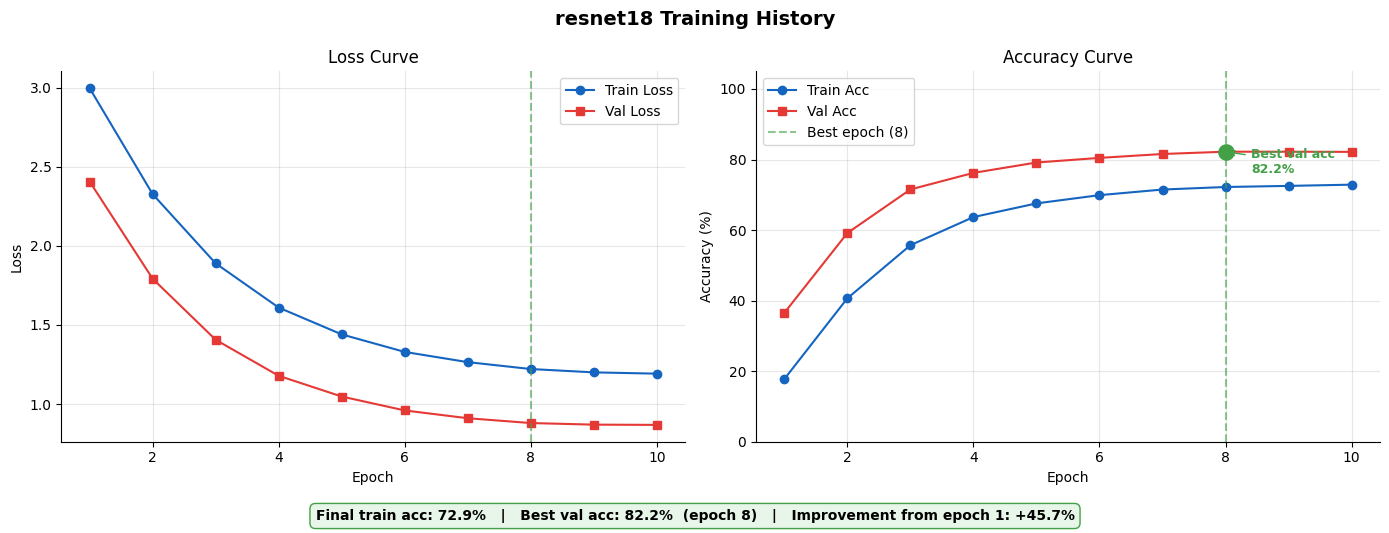

Starting: mobilenet_v2  (batch_size=256)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Biraj/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 17.6MB/s]


Model: mobilenet_v2 | Total params: 2,267,426 | Trainable params: 43,554

Starting training from scratch for mobilenet_v2



>> Epoch  1/10 summary | Train Loss: 2.0522, Train Acc: 49.46%, Val Loss: 0.9899, Val Acc: 80.80% | Best Val Acc: 80.80% | Time: 146.38s


>> Epoch  2/10 summary | Train Loss: 1.0440, Train Acc: 75.28%, Val Loss: 0.6037, Val Acc: 86.75% | Best Val Acc: 86.75% | Time: 119.90s


...

>> Epoch  6/10 summary | Train Loss: 0.6228, Train Acc: 82.72%, Val Loss: 0.3727, Val Acc: 90.18% | Best Val Acc: 90.28% | Time: 111.74s


>> Epoch  7/10 summary | Train Loss: 0.6070, Train Acc: 82.96%, Val Loss: 0.3571, Val Acc: 90.75% | Best Val Acc: 90.75% | Time: 121.58s


>> Epoch  8/10 summary | Train Loss: 0.5859, Train Acc: 83.21%, Val Loss: 0.3526, Val Acc: 90.75% | Best Val Acc: 90.75% | Time: 130.87s


>> Epoch  9/10 summary | Train Loss: 0.5843, Train Acc: 83.59%, Val Loss: 0.3479, Val Acc: 91.01% | Best Val Acc: 91.01% | Time: 125.19s


>> Epoch 10/10 summary | Train Loss: 0.5887, Train Acc: 83.36%, Val Loss: 0.3468, Val Acc: 90.89% | Best Val Acc: 91.01% | Time: 120.29s

Training completed in 20.68 minutes. Best validation accuracy: 91.01%


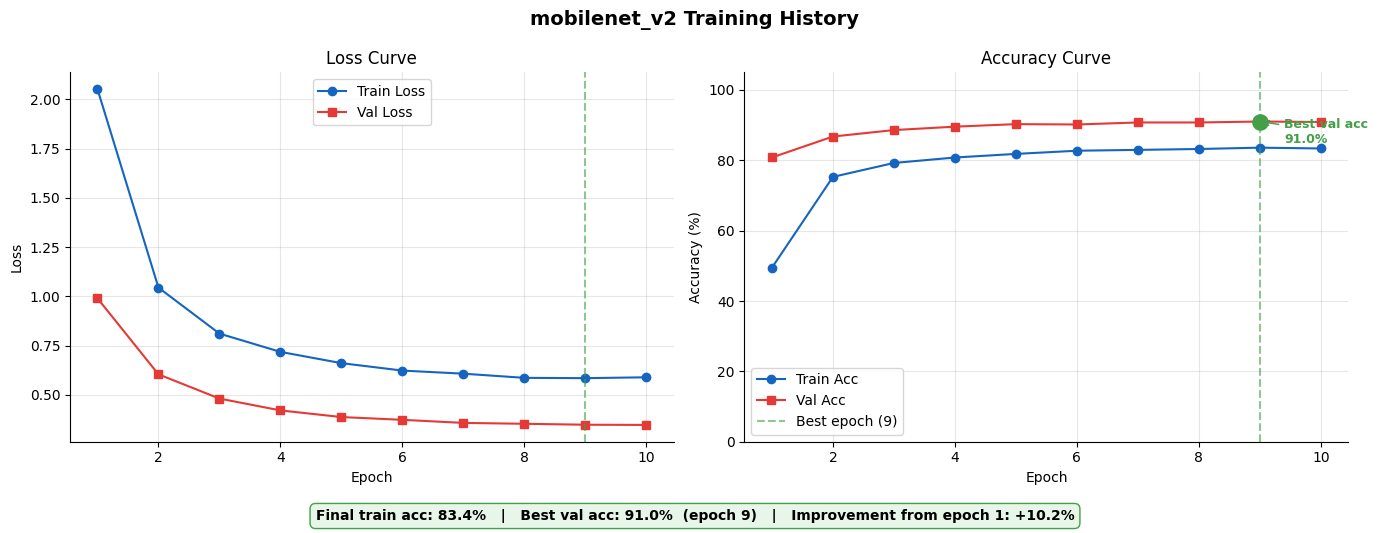

Starting: efficientnet_b0  (batch_size=256)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Biraj/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 10.4MB/s]


Model: efficientnet_b0 | Total params: 4,051,102 | Trainable params: 43,554

Starting training from scratch for efficientnet_b0



>> Epoch  1/10 summary | Train Loss: 2.3807, Train Acc: 45.71%, Val Loss: 1.3327, Val Acc: 77.23% | Best Val Acc: 77.23% | Time: 137.44s


>> Epoch  2/10 summary | Train Loss: 1.3981, Train Acc: 69.97%, Val Loss: 0.8113, Val Acc: 84.63% | Best Val Acc: 84.63% | Time: 120.75s


...

>> Epoch  6/10 summary | Train Loss: 0.8245, Train Acc: 78.69%, Val Loss: 0.4598, Val Acc: 89.18% | Best Val Acc: 89.18% | Time: 122.51s


>> Epoch  7/10 summary | Train Loss: 0.7941, Train Acc: 79.28%, Val Loss: 0.4445, Val Acc: 89.32% | Best Val Acc: 89.32% | Time: 121.36s


>> Epoch  8/10 summary | Train Loss: 0.7732, Train Acc: 79.67%, Val Loss: 0.4353, Val Acc: 89.29% | Best Val Acc: 89.32% | Time: 121.70s


>> Epoch  9/10 summary | Train Loss: 0.7627, Train Acc: 80.02%, Val Loss: 0.4257, Val Acc: 89.62% | Best Val Acc: 89.62% | Time: 126.95s


>> Epoch 10/10 summary | Train Loss: 0.7584, Train Acc: 79.96%, Val Loss: 0.4273, Val Acc: 89.41% | Best Val Acc: 89.62% | Time: 107.56s

Training completed in 20.51 minutes. Best validation accuracy: 89.62%


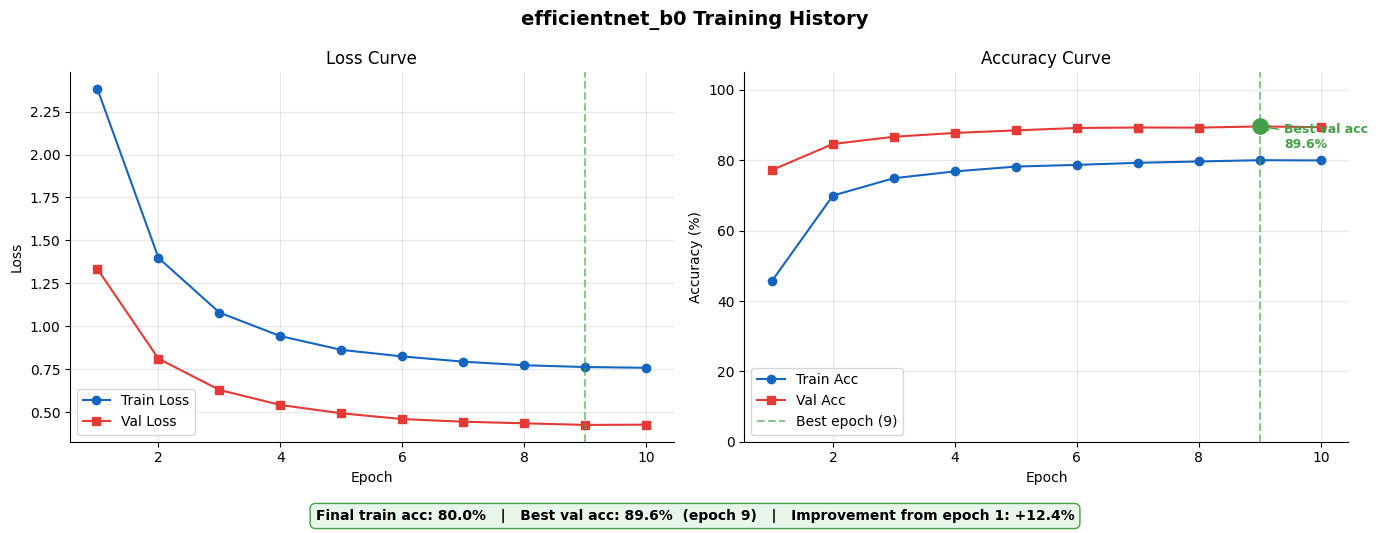

Starting: resnet50  (batch_size=16)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Biraj/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 8.89MB/s]


Model: resnet50 | Total params: 23,577,698 | Trainable params: 69,666

Starting training from scratch for resnet50



>> Epoch  1/10 summary | Train Loss: 1.7317, Train Acc: 57.62%, Val Loss: 0.7544, Val Acc: 82.96% | Best Val Acc: 82.96% | Time: 144.59s


>> Epoch  2/10 summary | Train Loss: 0.9383, Train Acc: 75.55%, Val Loss: 0.5064, Val Acc: 86.95% | Best Val Acc: 86.95% | Time: 127.73s


...

>> Epoch  6/10 summary | Train Loss: 0.6207, Train Acc: 81.59%, Val Loss: 0.3307, Val Acc: 90.42% | Best Val Acc: 91.07% | Time: 126.12s


>> Epoch  7/10 summary | Train Loss: 0.6006, Train Acc: 82.22%, Val Loss: 0.3127, Val Acc: 91.07% | Best Val Acc: 91.07% | Time: 126.65s


>> Epoch  8/10 summary | Train Loss: 0.5923, Train Acc: 82.45%, Val Loss: 0.3152, Val Acc: 90.94% | Best Val Acc: 91.07% | Time: 126.19s


>> Epoch  9/10 summary | Train Loss: 0.5834, Train Acc: 82.58%, Val Loss: 0.2999, Val Acc: 91.52% | Best Val Acc: 91.52% | Time: 125.79s


>> Epoch 10/10 summary | Train Loss: 0.5822, Train Acc: 82.76%, Val Loss: 0.3118, Val Acc: 90.90% | Best Val Acc: 91.52% | Time: 125.31s

Training completed in 21.41 minutes. Best validation accuracy: 91.52%


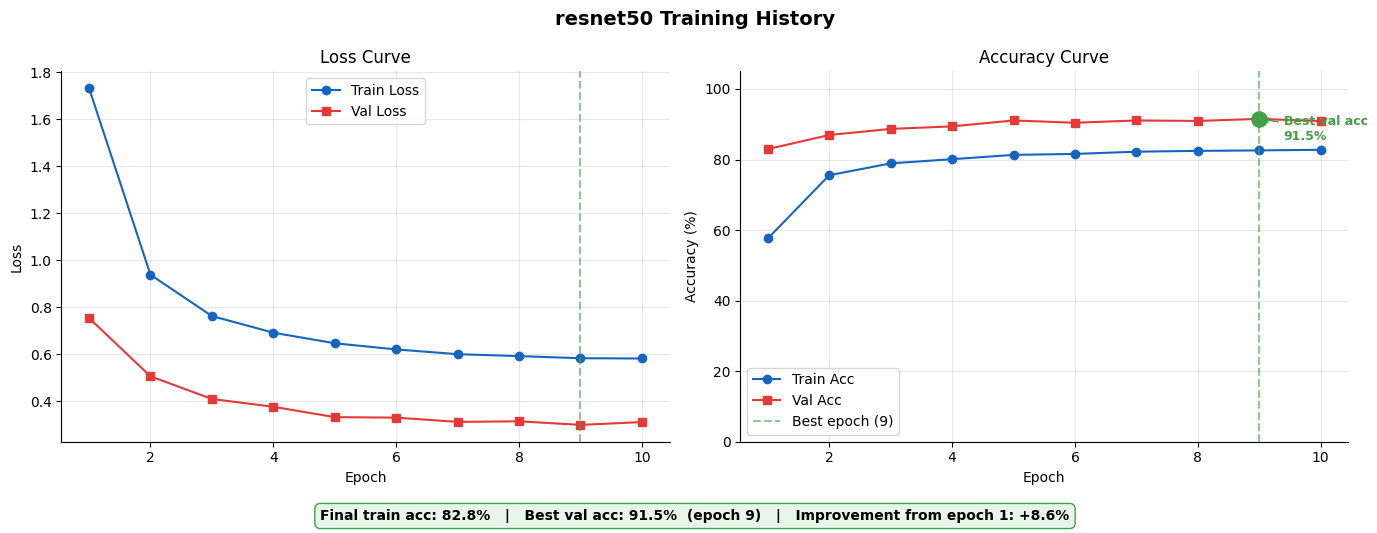

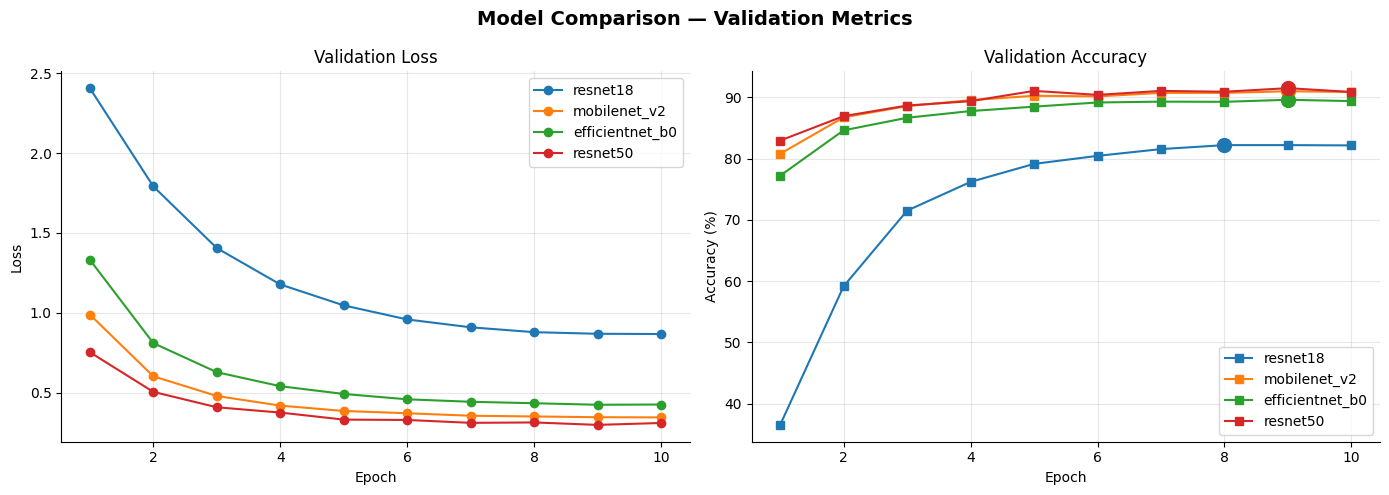


Comparison Summary
                Best Val Acc (%)  Best Epoch Final Val Acc (%)      LR
Model                                                                 
resnet18                   82.22           8             82.17  0.0001
mobilenet_v2               91.01           9             90.89  0.0003
efficientnet_b0            89.62           9             89.41  0.0003
resnet50                   91.52           9             90.90  0.0001


In [14]:
results = compare_models(
    configs,
    train_dir="data/train",
    validation_dir="data/val",
    device=device,
    checkpoint_dir="runs/train/cnn_finetune/checkpoints",
    backup_checkpoint_dir="runs/train/cnn_finetune/checkpoints_backup"

)

In [15]:
def save_model(results: Dict[str, Dict], model_name: str, save_dir: str = "saved_models"):
    data      = results[model_name]
    save_path = Path(save_dir)
    save_path.mkdir(exist_ok=True)

    weights_path = save_path / f"freshguard_{model_name}.pth"
    classes_path = save_path / "class_names.json"

    torch.save(data["model"].state_dict(), weights_path)
    with open(classes_path, "w") as f:
        json.dump(data["classes"], f, indent=2)

    print(f"Weights : {weights_path}")
    print(f"Classes : {classes_path} ({len(data['classes'])} classes)")

In [16]:
save_model(results, "resnet50", save_dir="models")

Weights : models\freshguard_resnet50.pth
Classes : models\class_names.json (34 classes)
